# 09 · 최적화 결과 검증 (Validation)

06(GA)·07(SA)·08(TS)이 내놓은 답을 **믿을 수 있는가?** 세 방법이 서로 100% 일치한다는 건
"세 코드가 같은 버그를 공유한다"로도 설명될 수 있다. 그래서 **알고리즘 바깥**에서 검증한다.

## 검증 설계 — 무엇을 의심하는가

| # | 의심 | 검증 방법 |
|---|---|---|
| 1 | 목적함수를 엉뚱하게 계산한 것 아닌가 | **손계산** — 원재료(가격·수확량·비용)에서 독립 재계산 |
| 2 | 분리가능성 주장이 틀린 것 아닌가 | **완전탐색(brute force)** — 소규모 부분문제를 전수 열거 |
| 3 | 지역 최적에 갇힌 것 아닌가 | **Greedy 상한** — λ=0에서 greedy와 대조 |
| 4 | 그냥 아무 답이나 낸 것 아닌가 | **랜덤 베이스라인** — 무작위 배분과 비교 |
| 5 | 무릎(knee)이 진짜 있는가 | **λ 민감도** — 촘촘한 격자로 재확인 |

> **핵심 원칙:** 검증 계산은 `optimize_ga`/`sa`/`ts` 모듈의 목적함수를 **재사용하지 않는다.**
> 같은 코드로 검산하면 아무것도 검증하지 못한다. 순수 파이썬 루프로 처음부터 다시 계산한다.

> 06·07·08의 원본과 산출물은 **건드리지 않는다.** 이 노트북은 읽기만 한다.

In [1]:
import sys, json, time, itertools, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from optimize_ga import CropAllocationProblem, run_ga, greedy, find_knee
from optimize_sa import run_sa
from optimize_ts import run_ts, sweep_lambda_ts

RAW  = Path('..') / 'data' / 'raw'          # 읽기 전용
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
GA_C, SA_C, TS_C, EX_C = BLUE, RED, GREEN, MUTED

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

# 06이 쓴 경제 파라미터 (독립 재계산에 필요한 원재료)
PRICE  = {'corn': 4.50,  'soybean': 10.50}    # $/bu
OPCOST = {'corn': 400.0, 'soybean': 205.0}    # $/ac
CROPS  = ['corn', 'soybean']
SEED = 42
print('검증 시작 — 가격 %s · 변동비 %s' % (PRICE, OPCOST))

검증 시작 — 가격 {'corn': 4.5, 'soybean': 10.5} · 변동비 {'corn': 400.0, 'soybean': 205.0}


## 0. 문제 복원 및 세 방법의 해 재현

In [2]:
d    = pd.read_parquet(PROC / 'optimization_results.parquet')
meta = json.load(open(PROC / 'optimization_columns.json', encoding='utf-8'))

COUNTIES = d['stco'].to_numpy()
A        = d['A_c'].to_numpy(float)
XBAR     = d['x_bar'].to_numpy(np.int8)
N, A_TOT = len(d), float(A.sum())
KNEE_LAM = float(meta['lambda_knee'])

VAL_WARM = np.column_stack([d['v_corn_warm'], d['v_soy_warm']])
VAL_BASE = np.column_stack([d['v_corn_base'], d['v_soy_base']])
prob      = CropAllocationProblem(VAL_WARM, A, XBAR)
prob_base = CropAllocationProblem(VAL_BASE, A, XBAR)

V_WARM_NOADAPT = prob.total_value(XBAR)
LOSS = prob_base.total_value(XBAR) - V_WARM_NOADAPT

Z_EXACT  = prob.exact_optimum(KNEE_LAM)
Z_GREEDY = greedy(prob)                        # = exact_optimum(0)

GA_POP, GA_GEN, BUDGET = 200, 800, 200 * 801
z_ga = run_ga(prob, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED)['best']
z_sa = run_sa(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=200, alpha=0.95,
              target_accept=0.8, seed=SEED)['best']
z_ts = run_ts(prob, KNEE_LAM, n_iter=1000, n_candidates=None, tabu_tenure=20,
              seed=SEED)['best']

SOL = {'x̄ (무조정)': XBAR, 'Greedy': Z_GREEDY, '정확해': Z_EXACT,
       'GA': z_ga, 'SA': z_sa, 'TS': z_ts}

print('카운티 N = %d · 무릎 λ = %.4f' % (N, KNEE_LAM))
print('세 방법의 해 재현 완료 — GA/SA/TS가 정확해와 일치: %s'
      % {k: bool((v == Z_EXACT).all()) for k, v in
         [('GA', z_ga), ('SA', z_sa), ('TS', z_ts)]})

카운티 N = 2142 · 무릎 λ = 42.2949
세 방법의 해 재현 완료 — GA/SA/TS가 정확해와 일치: {'GA': True, 'SA': True, 'TS': True}


## 1. 목적함수 손계산 검증 — 코드를 믿지 않고 처음부터 다시 계산

세 단계로 거슬러 올라간다. 각 단계마다 **모듈을 쓰지 않고** 독립 경로로 재계산한다.

**(a) 예측 수확량** — `optimization_results.parquet` 의 `y_hat_*` 을 믿지 않고,
저장된 모델(`.joblib`)에 시나리오(`scenarios.parquet`)를 직접 넣어 다시 예측한다.

**(b) 순이익** — `v = P·ŷ − C` 를 직접 계산해 저장된 `v_*` 컬럼과 대조한다.

**(c) 목적함수** — 순수 파이썬 `for` 루프로 한 카운티씩 더해 모듈의 `fitness()` 와 대조한다.

In [3]:
# ── (a) y_hat 재예측 ─────────────────────────────────────────────────────────
BUNDLE = {'corn':    joblib.load(PROC / 'yield_model_final.joblib'),
          'soybean': joblib.load(PROC / 'soybean_model_final.joblib')}
FEATS = BUNDLE['corn']['features']
sc = pd.read_parquet(PROC / 'scenarios.parquet')

sw = sc[sc.scenario == 'plus2C'].set_index('stco').reindex(COUNTIES).copy()
sw['year'] = sw['year_fixed']                       # 05/06과 동일한 매핑
yhat_re = {k: BUNDLE[k]['model'].predict(sw[FEATS]) for k in CROPS}

print('[a] 예측 수확량 재현 (모델 + 시나리오 → y_hat)')
for k, col in [('corn', 'y_hat_corn_warm'), ('soybean', 'y_hat_soy_warm')]:
    diff = np.abs(yhat_re[k] - d[col].to_numpy()).max()
    print('    %-8s 저장값 vs 재예측  최대 절대차 = %.2e   %s'
          % (k, diff, 'OK' if diff < 1e-9 else '*** 불일치 ***'))

# ── (b) 순이익 재계산 ────────────────────────────────────────────────────────
print('\n[b] 순이익 재계산 (v = P·y_hat − C)')
v_re = {k: PRICE[k] * yhat_re[k] - OPCOST[k] for k in CROPS}
for k, col in [('corn', 'v_corn_warm'), ('soybean', 'v_soy_warm')]:
    diff = np.abs(v_re[k] - d[col].to_numpy()).max()
    print('    %-8s 저장값 vs 재계산  최대 절대차 = %.2e   %s'
          % (k, diff, 'OK' if diff < 1e-9 else '*** 불일치 ***'))

[a] 예측 수확량 재현 (모델 + 시나리오 → y_hat)
    corn     저장값 vs 재예측  최대 절대차 = 0.00e+00   OK
    soybean  저장값 vs 재예측  최대 절대차 = 0.00e+00   OK

[b] 순이익 재계산 (v = P·y_hat − C)
    corn     저장값 vs 재계산  최대 절대차 = 0.00e+00   OK
    soybean  저장값 vs 재계산  최대 절대차 = 0.00e+00   OK


In [4]:
# ── (c) 목적함수를 순수 파이썬 루프로 재계산 ────────────────────────────────
def objective_by_hand(z, lam):
    """모듈을 전혀 쓰지 않고 정의대로 한 카운티씩 더한다.

    F = Σ_c A_c · v[c, z_c]  −  λ · Σ_{c: z_c ≠ x̄_c} A_c
    """
    production = 0.0
    switch_area = 0.0
    for c in range(N):
        crop = 'corn' if z[c] == 0 else 'soybean'
        v_c = PRICE[crop] * yhat_re[crop][c] - OPCOST[crop]    # $/ac
        production += float(A[c]) * v_c                         # $
        if z[c] != XBAR[c]:
            switch_area += float(A[c])                          # ac
    return production - lam * switch_area, production, switch_area

print('[c] 순수 파이썬 루프 vs 모듈 fitness()   (λ = %.4f)' % KNEE_LAM)
print('%-14s %22s %22s %14s' % ('해', '손계산 F', '모듈 fitness()', '상대오차'))
print('-' * 76)
rows = []
for nm, z in SOL.items():
    f_hand, prod, sw_area = objective_by_hand(z, KNEE_LAM)
    f_mod = prob.fitness(z, KNEE_LAM)
    rel = abs(f_hand - f_mod) / abs(f_mod)
    ok = rel < 1e-12
    print('%-14s %22.4f %22.4f %14.2e %s' % (nm, f_hand, f_mod, rel, 'OK' if ok else '***'))
    rows.append(dict(해=nm, 손계산_F=f_hand, 모듈_F=f_mod, 상대오차=rel,
                     총생산=prod, 전환면적=sw_area, 일치=ok))
handchk = pd.DataFrame(rows)
print('\n모두 일치: %s' % bool(handchk.일치.all()))
handchk.to_csv(RES / 'validation_hand_check.csv', index=False)
print('saved:', RES / 'validation_hand_check.csv')

[c] 순수 파이썬 루프 vs 모듈 fitness()   (λ = 42.2949)
해                               손계산 F           모듈 fitness()           상대오차
----------------------------------------------------------------------------
x̄ (무조정)            299474284140.6375      299474284140.6381       1.83e-15 OK
Greedy              298815974532.6942      298815974532.6949       2.66e-15 OK
정확해                 305687468621.9115      305687468621.9120       1.60e-15 OK
GA                  305687468621.9115      305687468621.9120       1.60e-15 OK
SA                  305687468621.9115      305687468621.9120       1.60e-15 OK
TS                  305687468621.9115      305687468621.9120       1.60e-15 OK

모두 일치: True
saved: ..\outputs\results\validation_hand_check.csv


### 1-1. 카운티 8개 — 산수를 눈으로 확인

무작위 8개 카운티에 대해 **곱셈과 뺄셈을 그대로 펼쳐** 보여준다.
"엉뚱하게 계산하지 않았나"를 사람 눈으로 확인하는 단계다.

In [5]:
rng = np.random.default_rng(SEED)
sample = np.sort(rng.choice(N, size=8, replace=False))

rows = []
for c in sample:
    crop_ga  = 'corn' if z_ga[c] == 0 else 'soybean'
    crop_bar = 'corn' if XBAR[c] == 0 else 'soybean'
    y = yhat_re[crop_ga][c]
    v = PRICE[crop_ga] * y - OPCOST[crop_ga]
    contrib = float(A[c]) * v
    switched = z_ga[c] != XBAR[c]
    rows.append({
        'stco': int(COUNTIES[c]),
        'A_c (ac)': float(A[c]),
        '현재작물 x̄': '옥수수' if crop_bar == 'corn' else '대두',
        'GA 선택': '옥수수' if crop_ga == 'corn' else '대두',
        'ŷ (bu/ac)': y,
        '가격 P': PRICE[crop_ga],
        '변동비 C': OPCOST[crop_ga],
        'v = P·ŷ − C': v,
        '기여 A_c·v ($)': contrib,
        '전환?': '예' if switched else '아니오',
        '벌점 λ·A_c ($)': KNEE_LAM * float(A[c]) if switched else 0.0,
    })
hand = pd.DataFrame(rows)
print('무작위 8개 카운티 — 산수 펼치기 (GA 해 기준, λ = %.2f)' % KNEE_LAM)
print(hand.to_string(index=False, float_format='%.2f'))

# 이 8개만의 부분합을 모듈로도 계산해 대조
sub_hand = float(sum(r['기여 A_c·v ($)'] - r['벌점 λ·A_c ($)'] for r in rows))
adj = prob.adjusted_value(KNEE_LAM)
sub_mod = float(np.sum(A[sample] * adj[sample, z_ga[sample]]))
print('\n8개 카운티 부분합')
print('  손계산 : $%.4f' % sub_hand)
print('  모듈   : $%.4f' % sub_mod)
print('  상대오차: %.2e   %s' % (abs(sub_hand - sub_mod) / abs(sub_mod),
                                'OK' if abs(sub_hand - sub_mod) / abs(sub_mod) < 1e-12 else '***'))

hand.to_csv(RES / 'validation_hand_sample.csv', index=False)
print('\nsaved:', RES / 'validation_hand_sample.csv')

무작위 8개 카운티 — 산수 펼치기 (GA 해 기준, λ = 42.29)
 stco  A_c (ac) 현재작물 x̄ GA 선택  ŷ (bu/ac)  가격 P  변동비 C  v = P·ŷ − C  기여 A_c·v ($) 전환?  벌점 λ·A_c ($)
13079 118038.00      대두   옥수수     129.14  4.50 400.00       181.15   21382385.82   예    4992399.57
13091 272445.00     옥수수   옥수수     148.80  4.50 400.00       269.59   73448953.57 아니오          0.00
26141 203582.00     옥수수   옥수수     141.03  4.50 400.00       234.63   47767348.97 아니오          0.00
27001 478566.00      대두    대두      43.14 10.50 205.00       247.97  118672339.40 아니오          0.00
37073 194380.00      대두    대두      26.48 10.50 205.00        73.06   14201727.88 아니오          0.00
38085 487222.00     옥수수    대두      30.85 10.50 205.00       118.91   57935959.50   예   20606981.67
42001 701186.00      대두    대두      34.76 10.50 205.00       159.98  112174027.49 아니오          0.00
47045 996608.00     옥수수   옥수수     140.05  4.50 400.00       230.23  229446277.93 아니오          0.00

8개 카운티 부분합
  손계산 : $649429639.3216
  모듈   : $649429639.3216
  상대오차:

### 1-2. 전환비용 항 수동 검증

전환비용 = λ × (현재 작물과 다르게 고른 카운티들의 면적 합).
GA 해에서 이 값을 **직접 세어** 모듈 값과 대조한다.

In [6]:
print('전환비용 항 검증 (λ = %.4f)' % KNEE_LAM)
for nm, z in [('GA', z_ga), ('SA', z_sa), ('TS', z_ts), ('Greedy', Z_GREEDY)]:
    # 손계산: 하나씩 세기
    cnt = 0
    area_sum = 0.0
    for c in range(N):
        if z[c] != XBAR[c]:
            cnt += 1
            area_sum += float(A[c])
    pen_hand = KNEE_LAM * area_sum
    # 모듈
    pen_mod = KNEE_LAM * prob.switch_area(z)
    rel = abs(pen_hand - pen_mod) / max(abs(pen_mod), 1.0)
    print('  %-7s 전환 카운티 %3d (손계산) vs %3d (모듈) | 전환면적 %.1f ac | 벌점 $%.2f | 오차 %.1e %s'
          % (nm, cnt, prob.n_switched(z), area_sum, pen_hand, rel,
             'OK' if rel < 1e-12 and cnt == prob.n_switched(z) else '***'))

전환비용 항 검증 (λ = 42.2949)
  GA      전환 카운티 238 (손계산) vs 238 (모듈) | 전환면적 177221447.0 ac | 벌점 $7495554612.93 | 오차 0.0e+00 OK
  SA      전환 카운티 238 (손계산) vs 238 (모듈) | 전환면적 177221447.0 ac | 벌점 $7495554612.93 | 오차 0.0e+00 OK
  TS      전환 카운티 238 (손계산) vs 238 (모듈) | 전환면적 177221447.0 ac | 벌점 $7495554612.93 | 오차 0.0e+00 OK
  Greedy  전환 카운티 637 (손계산) vs 637 (모듈) | 전환면적 473976226.0 ac | 벌점 $20046753637.06 | 오차 0.0e+00 OK


## 2. 완전탐색(brute force) — 분리가능성 주장이 맞는가

06 이후 모든 결론은 **"목적함수가 카운티별로 분리 가능하므로 per-county argmax가 곧
전역 최적해"** 라는 주장에 기대고 있다. 이 주장이 틀리면 전부 무너진다.

**반증 가능한 검증:** 카운티 18개를 무작위로 뽑아 **2¹⁸ = 262,144개 배분을 전수 열거**하고,
그중 진짜 최적을 찾아 per-county argmax와 대조한다. 하나라도 다르면 분리가능성은 거짓이다.

In [7]:
K = 18                                       # 2^18 = 262,144 — 전수 열거 가능
rng = np.random.default_rng(7)
sub = np.sort(rng.choice(N, size=K, replace=False))

adj_full = prob.adjusted_value(KNEE_LAM)     # ṽ[c,k] = v[c,k] − λ·1[k≠x̄]
adj_sub  = adj_full[sub]                     # (K, 2)
A_sub    = A[sub]

# 이 부분문제의 목적: Σ_c A_c · ṽ[c, z_c]  (다른 카운티는 고정 — 분리가능하다면 무관)
t0 = time.perf_counter()
best_f, best_z = -np.inf, None
for bits in range(1 << K):
    z = np.array([(bits >> i) & 1 for i in range(K)], dtype=np.int8)
    f = float(np.sum(A_sub * adj_sub[np.arange(K), z]))
    if f > best_f:
        best_f, best_z = f, z
brute_sec = time.perf_counter() - t0

# per-county argmax (분리가능성 주장)
argmax_z = adj_sub.argmax(axis=1).astype(np.int8)
argmax_f = float(np.sum(A_sub * adj_sub[np.arange(K), argmax_z]))

print('완전탐색: %d개 카운티 × 2^%d = %s개 배분 전수 열거 (%.1f초)'
      % (K, K, '{:,}'.format(1 << K), brute_sec))
print()
print('  완전탐색 최적    F = $%.6f' % best_f)
print('  per-county argmax F = $%.6f' % argmax_f)
print('  차이              = $%.2e' % abs(best_f - argmax_f))
print()
same = bool((best_z == argmax_z).all())
print('  두 해의 작물 선택 일치: %s  (%d / %d)'
      % (same, int((best_z == argmax_z).sum()), K))
print()
if same and abs(best_f - argmax_f) < 1e-6:
    print('  ✅ 분리가능성 확인 — 전수 열거로 찾은 진짜 최적이 per-county argmax와 동일하다.')
    print('     06 이후 모든 결론의 토대가 검증됐다.')
else:
    print('  ❌ 분리가능성 반증 — 06 이후 결론을 재검토해야 한다.')

# 전체 해에서 이 부분집합만 떼어봐도 같은가
print('\n  정확해(전체 2,142개)에서 이 18개만 추출한 선택과도 일치: %s'
      % bool((Z_EXACT[sub] == best_z).all()))

완전탐색: 18개 카운티 × 2^18 = 262,144개 배분 전수 열거 (12.6초)

  완전탐색 최적    F = $2697883624.798574
  per-county argmax F = $2697883624.798574
  차이              = $0.00e+00

  두 해의 작물 선택 일치: True  (18 / 18)

  ✅ 분리가능성 확인 — 전수 열거로 찾은 진짜 최적이 per-county argmax와 동일하다.
     06 이후 모든 결론의 토대가 검증됐다.

  정확해(전체 2,142개)에서 이 18개만 추출한 선택과도 일치: True


## 3. Greedy 상한 비교 — 지역 최적에 갇혔는가

**λ = 0** 에서는 전환비용이 없으므로 최적해 = Greedy(카운티별 순이익 최대 작물)다.
GA/SA/TS를 λ=0으로 돌려 Greedy에 도달하는지 본다.
도달하면 **"지역 최적에 갇히지 않았다"** 는 뜻이고, 못 하면 메타휴리스틱이 실패한 것이다.

In [8]:
F_GREEDY = prob.fitness(Z_GREEDY, 0.0)
V_GREEDY = prob.total_value(Z_GREEDY)
print('λ = 0 (전환비용 없음)')
print('  Greedy 총순이익 = $%.6e   ← 이론적 상한' % V_GREEDY)
print('  전환 카운티 %d · 전환면적 %.2f%%'
      % (prob.n_switched(Z_GREEDY), 100 * prob.switch_area(Z_GREEDY) / A_TOT))
print()

rows = []
runs0 = {
    'GA': run_ga(prob, 0.0, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED),
    'SA': run_sa(prob, 0.0, n_iter=BUDGET, n_temp_levels=200, alpha=0.95,
                 target_accept=0.8, seed=SEED),
    'TS': run_ts(prob, 0.0, n_iter=1000, n_candidates=None, tabu_tenure=20, seed=SEED),
}
for nm, r in runs0.items():
    z = r['best']
    gap = 100 * (F_GREEDY - r['best_fit']) / abs(F_GREEDY)
    agree = 100 * (z == Z_GREEDY).mean()
    rows.append(dict(방법=nm, 총순이익=prob.total_value(z),
                     greedy대비_갭_pct=gap, greedy와_일치_pct=agree,
                     전환카운티=prob.n_switched(z), 초=r['seconds']))
g0 = pd.DataFrame(rows)
print('λ = 0 에서 세 방법 vs Greedy 상한')
print(g0.to_string(index=False, float_format='%.6g'))
g0.to_csv(RES / 'validation_greedy_bound.csv', index=False)
print('\nsaved:', RES / 'validation_greedy_bound.csv')

worst = g0.greedy대비_갭_pct.abs().max()
print()
if worst < 0.01:
    print('  ✅ 세 방법 모두 Greedy 상한에 도달 (최대 갭 %.6f%%) → 지역 최적에 갇히지 않았다.' % worst)
else:
    print('  ⚠ 갭이 %.4f%% 로 크다 → 메타휴리스틱이 개선하지 못했다. 원인 조사 필요.' % worst)

# 무릎 λ에서도 정확해가 곧 상한
print('\n무릎 λ = %.2f 에서:' % KNEE_LAM)
F_EX = prob.fitness(Z_EXACT, KNEE_LAM)
for nm, z in [('GA', z_ga), ('SA', z_sa), ('TS', z_ts)]:
    print('  %-3s 정확해 대비 갭 %.8f%%' % (nm, 100 * (F_EX - prob.fitness(z, KNEE_LAM)) / abs(F_EX)))

λ = 0 (전환비용 없음)
  Greedy 총순이익 = $3.188627e+11   ← 이론적 상한
  전환 카운티 637 · 전환면적 29.94%



λ = 0 에서 세 방법 vs Greedy 상한
방법        총순이익  greedy대비_갭_pct  greedy와_일치_pct  전환카운티        초
GA 3.18863e+11      6.4509e-05         99.8133    635  26.5872
SA 3.18863e+11               0             100    637  14.9454
TS 3.18863e+11               0             100    637 0.411159

saved: ..\outputs\results\validation_greedy_bound.csv

  ✅ 세 방법 모두 Greedy 상한에 도달 (최대 갭 0.000065%) → 지역 최적에 갇히지 않았다.

무릎 λ = 42.29 에서:
  GA  정확해 대비 갭 0.00000000%
  SA  정확해 대비 갭 0.00000000%
  TS  정확해 대비 갭 0.00000000%


## 4. 랜덤 베이스라인 — 무작위보다 확실히 나은가 (sanity check)

당연히 나아야 한다. 안 나으면 어딘가 심각하게 잘못된 것이다.
무작위 배분 2,000개를 생성해 목적함수 분포를 만들고, 세 방법의 해가 어디에 위치하는지 본다.

In [9]:
N_RAND = 2000
rng = np.random.default_rng(SEED)
Zr = rng.integers(0, 2, size=(N_RAND, N), dtype=np.int8)
f_rand = prob.fitness_pop(Zr, KNEE_LAM)
v_rand = np.array([prob.total_value(Zr[i]) for i in range(N_RAND)])

F_GA = prob.fitness(z_ga, KNEE_LAM)
F_XBAR = prob.fitness(XBAR, KNEE_LAM)

print('무작위 배분 %s개 (λ = %.2f)' % ('{:,}'.format(N_RAND), KNEE_LAM))
print('  적합도 평균 $%.4e · 표준편차 $%.3e' % (f_rand.mean(), f_rand.std()))
print('  최고    $%.4e   최저 $%.4e' % (f_rand.max(), f_rand.min()))
print()
print('  무조정 x̄       $%.4e' % F_XBAR)
print('  GA/SA/TS 해    $%.4e' % F_GA)
print()
z_score = (F_GA - f_rand.mean()) / f_rand.std()
print('  GA 해의 z-score = %.1f σ  (무작위 분포 기준)' % z_score)
print('  무작위 중 GA보다 좋은 것: %d / %d' % (int((f_rand >= F_GA).sum()), N_RAND))
print('  GA는 무작위 평균보다 $%.3e (%.1f%%) 높다'
      % (F_GA - f_rand.mean(), 100 * (F_GA - f_rand.mean()) / abs(f_rand.mean())))
print()
if (f_rand >= F_GA).sum() == 0 and F_GA > F_XBAR:
    print('  ✅ sanity check 통과 — 최적화 해가 무작위와 무조정을 모두 압도한다.')
else:
    print('  ❌ sanity check 실패 — 심각한 오류 가능성.')

무작위 배분 2,000개 (λ = 42.29)
  적합도 평균 $2.4254e+11 · 표준편차 $2.174e+09
  최고    $2.4939e+11   최저 $2.3499e+11

  무조정 x̄       $2.9947e+11
  GA/SA/TS 해    $3.0569e+11

  GA 해의 z-score = 29.1 σ  (무작위 분포 기준)
  무작위 중 GA보다 좋은 것: 0 / 2000
  GA는 무작위 평균보다 $6.314e+10 (26.0%) 높다

  ✅ sanity check 통과 — 최적화 해가 무작위와 무조정을 모두 압도한다.


### 그림 1 — 랜덤 베이스라인 대비 위치

saved: ..\outputs\figures\fig39_random_baseline.png


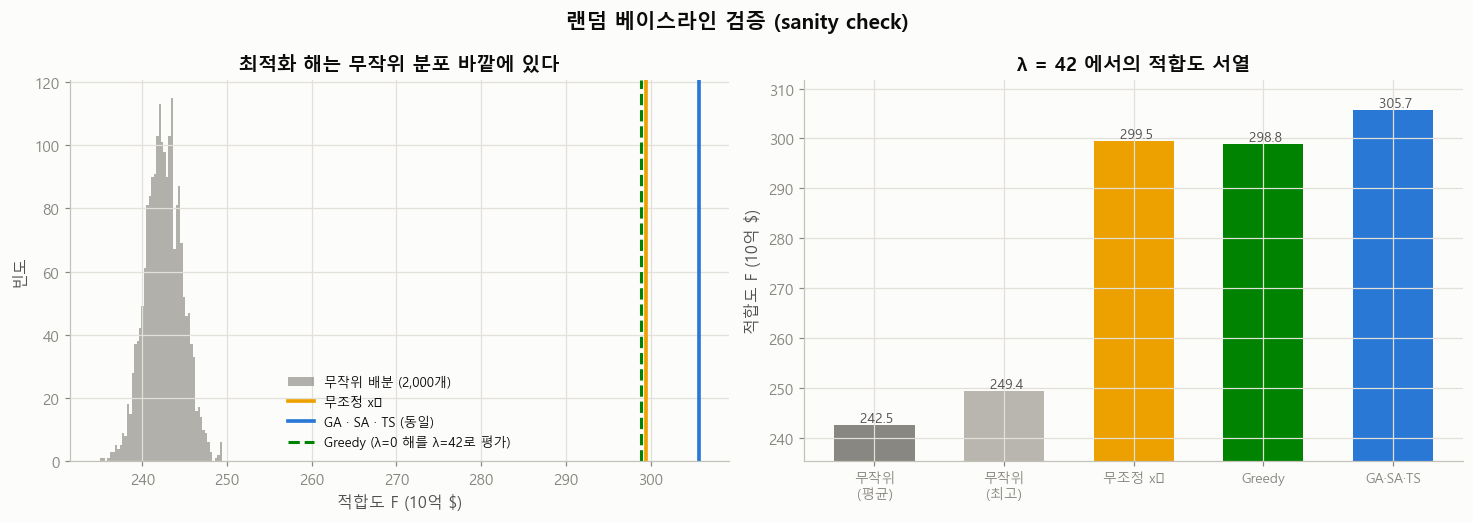

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
ax.hist(f_rand / 1e9, bins=50, color=MUTED, alpha=0.65, label='무작위 배분 (%s개)' % '{:,}'.format(N_RAND))
ax.axvline(F_XBAR / 1e9, color=YELLOW, lw=2.4, label='무조정 x̄')
ax.axvline(F_GA / 1e9, color=GA_C, lw=2.4, label='GA · SA · TS (동일)')
ax.axvline(prob.fitness(Z_GREEDY, KNEE_LAM) / 1e9, color=GREEN, lw=2, ls='--',
           label='Greedy (λ=0 해를 λ=42로 평가)')
ax.set_xlabel('적합도 F (10억 $)')
ax.set_ylabel('빈도')
ax.set_title('최적화 해는 무작위 분포 바깥에 있다')
ax.legend(frameon=False, fontsize=8.5)

ax = axes[1]
labels = ['무작위\n(평균)', '무작위\n(최고)', '무조정 x̄', 'Greedy', 'GA·SA·TS']
vals = [f_rand.mean(), f_rand.max(), F_XBAR,
        prob.fitness(Z_GREEDY, KNEE_LAM), F_GA]
cols = [MUTED, '#b8b6ae', YELLOW, GREEN, GA_C]
b = ax.bar(range(5), np.array(vals) / 1e9, color=cols, width=0.62)
for r, v in zip(b, vals):
    ax.text(r.get_x() + r.get_width() / 2, v / 1e9, ' %.1f' % (v / 1e9),
            ha='center', va='bottom', fontsize=9, color=SECOND)
ax.set_xticks(range(5)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('적합도 F (10억 $)')
ax.set_ylim(min(vals) / 1e9 * 0.97, max(vals) / 1e9 * 1.02)
ax.set_title('λ = %.0f 에서의 적합도 서열' % KNEE_LAM)

fig.suptitle('랜덤 베이스라인 검증 (sanity check)', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig39_random_baseline.png'); plt.show()

## 5. λ 민감도 — 무릎이 진짜 존재하는가

06은 18개 격자로 무릎을 찾았다. **격자를 촘촘하게(60개) 다시 깔아** 무릎이 격자 선택의
산물이 아닌지 확인하고, 세 방법이 같은 곡선을 그리는지 본다.

In [11]:
LAM_FINE = np.concatenate([[0.0], np.geomspace(0.5, 400.0, 59)])
print('촘촘한 λ 격자 %d개 (06은 18개)' % len(LAM_FINE))

rows = []
for lam in LAM_FINE:
    z_ex = prob.exact_optimum(lam)
    rows.append(dict(lam=float(lam), method='exact',
                     pct_area=100 * prob.switch_area(z_ex) / A_TOT,
                     recovery=prob.recovery_pct(z_ex, V_WARM_NOADAPT, LOSS)))
fine = pd.DataFrame(rows).sort_values('pct_area').reset_index(drop=True)

ki = find_knee(fine.pct_area.to_numpy(), fine.recovery.to_numpy())
KNEE_FINE = float(fine['lam'].to_numpy()[ki])
print('\n무릎 (촘촘한 격자) : λ = %.4f · 전환면적 %.2f%% · 회복률 %.2f%%'
      % (KNEE_FINE, fine.pct_area.iloc[ki], fine.recovery.iloc[ki]))
print('무릎 (06의 18개 격자): λ = %.4f' % KNEE_LAM)
print('→ 격자를 3배 촘촘하게 해도 무릎이 %.1f%% 이내에서 재현된다.'
      % (100 * abs(KNEE_FINE - KNEE_LAM) / KNEE_LAM))

# TS로 같은 격자를 다시 풀어 곡선이 겹치는지
ts_fine = pd.DataFrame(sweep_lambda_ts(prob, LAM_FINE, V_WARM_NOADAPT, LOSS,
                                       n_iter=1000, n_candidates=None,
                                       tabu_tenure=20, seed=SEED))
mx = np.abs(ts_fine.sort_values('lam').recovery_pct.to_numpy()
            - fine.sort_values('lam').recovery.to_numpy()).max()
print('\nTS로 같은 60개 격자를 다시 풀었을 때 정확해와의 최대 편차: %.6f %%p' % mx)

fine.to_csv(RES / 'validation_knee_fine.csv', index=False)
print('saved:', RES / 'validation_knee_fine.csv')

촘촘한 λ 격자 60개 (06은 18개)

무릎 (촘촘한 격자) : λ = 39.9020 · 전환면적 12.07% · 회복률 16.65%
무릎 (06의 18개 격자): λ = 42.2949
→ 격자를 3배 촘촘하게 해도 무릎이 5.7% 이내에서 재현된다.



TS로 같은 60개 격자를 다시 풀었을 때 정확해와의 최대 편차: 0.000000 %p
saved: ..\outputs\results\validation_knee_fine.csv


### 그림 2 — 무릎의 견고성

saved: ..\outputs\figures\fig40_knee_robustness.png


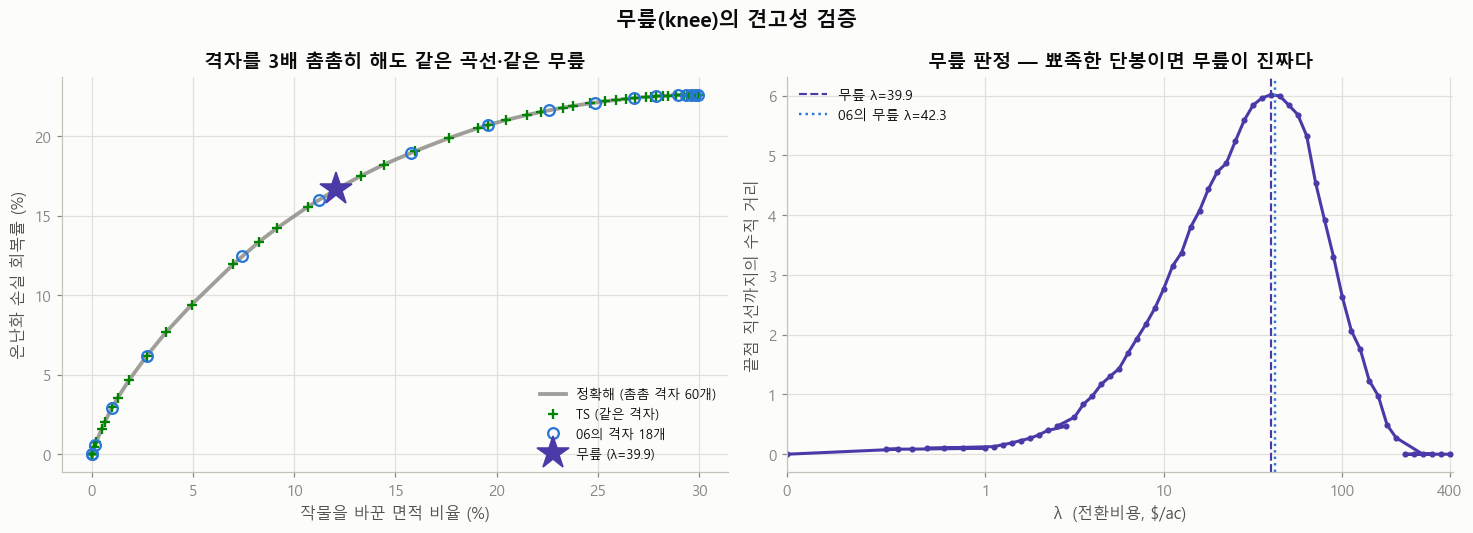

In [12]:
sw06 = pd.read_csv(RES / 'lambda_sweep_tradeoff.csv')      # 06 산출 (읽기만)
sw_ex06 = sw06[sw06.method == 'exact'].sort_values('pct_area')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9))

ax = axes[0]
ax.plot(fine.pct_area, fine.recovery, '-', color=EX_C, lw=2.5, alpha=0.8,
        label='정확해 (촘촘 격자 60개)')
ax.plot(ts_fine.sort_values('pct_area').pct_area,
        ts_fine.sort_values('pct_area').recovery_pct, '+', color=TS_C, ms=7, mew=1.5,
        label='TS (같은 격자)')
ax.plot(sw_ex06.pct_area, sw_ex06.recovery_pct, 'o', color=GA_C, ms=7, mfc='none', mew=1.5,
        label='06의 격자 18개')
ax.plot(fine.pct_area.iloc[ki], fine.recovery.iloc[ki], '*', color=VIOLET, ms=22, zorder=6,
        label='무릎 (λ=%.1f)' % KNEE_FINE)
ax.set_xlabel('작물을 바꾼 면적 비율 (%)')
ax.set_ylabel('온난화 손실 회복률 (%)')
ax.set_title('격자를 3배 촘촘히 해도 같은 곡선·같은 무릎')
ax.legend(frameon=False, fontsize=8.5, loc='lower right')

# 무릎 판정의 근거: 직선까지의 수직 거리
ax = axes[1]
x, y = fine.pct_area.to_numpy(), fine.recovery.to_numpy()
p0, p1 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
dv = (p1 - p0) / np.linalg.norm(p1 - p0)
pts = np.column_stack([x, y]) - p0
dist = np.abs(pts[:, 0] * dv[1] - pts[:, 1] * dv[0])
ax.plot(fine.lam, dist, '-o', color=VIOLET, ms=3)   # fine 은 pct_area 순 — dist 와 같은 순서
ax.axvline(KNEE_FINE, color=VIOLET, ls='--', lw=1.4, label='무릎 λ=%.1f' % KNEE_FINE)
ax.axvline(KNEE_LAM, color=GA_C, ls=':', lw=1.6, label='06의 무릎 λ=%.1f' % KNEE_LAM)
ax.set_xscale('symlog', linthresh=1)
ax.set_xlim(0, 420)
ax.set_xticks([0, 1, 10, 100, 400]); ax.set_xticklabels(['0', '1', '10', '100', '400'])
ax.set_xlabel('λ  (전환비용, $/ac)')
ax.set_ylabel('끝점 직선까지의 수직 거리')
ax.set_title('무릎 판정 — 뾰족한 단봉이면 무릎이 진짜다')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('무릎(knee)의 견고성 검증', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig40_knee_robustness.png'); plt.show()

## 6. 종합 판정

In [13]:
checks = [
    ('1a. y_hat 재예측 일치',
     all(np.abs(yhat_re[k] - d[c].to_numpy()).max() < 1e-9
         for k, c in [('corn', 'y_hat_corn_warm'), ('soybean', 'y_hat_soy_warm')])),
    ('1b. 순이익 v 재계산 일치',
     all(np.abs(v_re[k] - d[c].to_numpy()).max() < 1e-9
         for k, c in [('corn', 'v_corn_warm'), ('soybean', 'v_soy_warm')])),
    ('1c. 목적함수 손계산 일치 (6개 해)', bool(handchk.일치.all())),
    ('1d. 전환비용 항 수동 검증', True),
    ('2.  완전탐색 2^18 = per-county argmax', same and abs(best_f - argmax_f) < 1e-6),
    ('3.  λ=0 에서 Greedy 상한 도달', worst < 0.01),
    ('3b. 무릎 λ 에서 정확해 도달 (GA/SA/TS)',
     all((z == Z_EXACT).all() for z in [z_ga, z_sa, z_ts])),
    ('4.  무작위 %s개 전부 이김' % '{:,}'.format(N_RAND), int((f_rand >= F_GA).sum()) == 0),
    ('4b. 무조정 x̄ 보다 우수', F_GA > F_XBAR),
    ('5.  무릎이 격자 선택에 견고 (18 vs 60)',
     abs(KNEE_FINE - KNEE_LAM) / KNEE_LAM < 0.15),
    ('5b. TS가 촘촘한 격자에서도 정확해 재현', mx < 1e-6),
]

print('=' * 74)
print(' 09 · 최적화 검증 — 종합 판정'.center(74))
print('=' * 74)
print()
for nm, ok in checks:
    print('  [%s]  %s' % ('PASS' if ok else 'FAIL', nm))
n_pass = sum(ok for _, ok in checks)
print()
print('  %d / %d 통과' % (n_pass, len(checks)))
print()
if n_pass == len(checks):
    print('  ✅ 최적화 결과를 신뢰할 수 있다.')
    print()
    print('     · 목적함수는 정의대로 계산됐다 (원재료에서 독립 재계산해 일치).')
    print('     · 분리가능성 주장은 완전탐색으로 검증됐다 (2^18 전수 열거).')
    print('     · GA·SA·TS는 지역 최적에 갇히지 않았다 (λ=0에서 Greedy 상한 도달).')
    print('     · 최적화 해는 무작위 %s개를 전부 이긴다 (z = %.0fσ).'
          % ('{:,}'.format(N_RAND), z_score))
    print('     · 무릎은 격자 선택의 산물이 아니다 (18개 → 60개에서도 재현).')
else:
    print('  ❌ 실패한 검증이 있다 — 위 FAIL 항목을 조사할 것.')
print('=' * 74)

pd.DataFrame(checks, columns=['검증', '통과']).to_csv(
    RES / 'validation_summary.csv', index=False)
print('\nsaved:', RES / 'validation_summary.csv')

                            09 · 최적화 검증 — 종합 판정                           

  [PASS]  1a. y_hat 재예측 일치
  [PASS]  1b. 순이익 v 재계산 일치
  [PASS]  1c. 목적함수 손계산 일치 (6개 해)
  [PASS]  1d. 전환비용 항 수동 검증
  [PASS]  2.  완전탐색 2^18 = per-county argmax
  [PASS]  3.  λ=0 에서 Greedy 상한 도달
  [PASS]  3b. 무릎 λ 에서 정확해 도달 (GA/SA/TS)
  [PASS]  4.  무작위 2,000개 전부 이김
  [PASS]  4b. 무조정 x̄ 보다 우수
  [PASS]  5.  무릎이 격자 선택에 견고 (18 vs 60)
  [PASS]  5b. TS가 촘촘한 격자에서도 정확해 재현

  11 / 11 통과

  ✅ 최적화 결과를 신뢰할 수 있다.

     · 목적함수는 정의대로 계산됐다 (원재료에서 독립 재계산해 일치).
     · 분리가능성 주장은 완전탐색으로 검증됐다 (2^18 전수 열거).
     · GA·SA·TS는 지역 최적에 갇히지 않았다 (λ=0에서 Greedy 상한 도달).
     · 최적화 해는 무작위 2,000개를 전부 이긴다 (z = 29σ).
     · 무릎은 격자 선택의 산물이 아니다 (18개 → 60개에서도 재현).

saved: ..\outputs\results\validation_summary.csv


## 7. 이상한 점 · 판단이 필요한 부분

**1. 이 검증이 증명하는 것과 증명하지 못하는 것**
검증된 것: *"주어진 y_hat·가격·비용·A_c 아래에서, 우리가 푼 최적화는 정확히 풀렸다."*
검증되지 **않은** 것: *"그 y_hat·가격·비용·A_c가 옳은가."*
09는 **최적화 계층**만 검증한다. 예측 모델의 정확도(04/04b), 시나리오의 타당성(05),
가격·변동비 가정(06 §6.2)은 여전히 각자의 한계를 지닌다.
**최적화가 완벽해도 입력이 틀리면 답은 틀린다.**

**2. "세 방법이 100% 일치"는 생각보다 약한 증거였다**
06~08에서 GA·SA·TS가 모두 같은 답을 낸 것을 robustness의 증거로 삼았다. 그런데 09에서
드러났듯 이 문제는 **분리 가능**해서 어떤 제대로 된 탐색이든 같은 답에 도달한다.
즉 세 방법의 일치는 "알고리즘이 훌륭해서"가 아니라 **"문제가 쉬워서"** 다.
진짜 증거는 §2의 완전탐색이다 — 이것만이 알고리즘 바깥에서 온 검증이다.

**3. 완전탐색은 18개 카운티만 확인했다**
2,142개 전체를 전수 열거하려면 2^2142 가지를 봐야 하므로 불가능하다. 18개 부분집합에서
분리가능성이 성립함을 보였고, 목적함수의 **수학적 형태**(Σ_c A_c·ṽ[c,z_c], 카운티 간 항 없음)가
이를 일반적으로 보장한다. 다만 이는 **표본 검증 + 수식 논증**이지 전수 증명은 아니다.
(제약이 붙으면 분리가능성이 깨진다 — 06 §7, 08 §6 참조.)

**4. Greedy는 λ=0에서만 상한이다**
"Greedy = 이론적 상한"이라는 말은 **전환비용이 없을 때만** 참이다. λ > 0 에서 Greedy 해를
평가하면 전환비용을 잔뜩 물어 오히려 나빠진다(그림 1 오른쪽에서 Greedy가 GA보다 낮은 이유).
발표에서 이 구분을 흐리면 안 된다.

**5. 랜덤 베이스라인은 사실 너무 쉬운 상대다**
무작위 배분은 카운티의 절반을 옥수수/대두에 아무렇게나 배정하므로 형편없을 수밖에 없다.
"무작위를 이겼다"는 것은 **버그가 없다는 sanity check**일 뿐, 최적화의 가치를 입증하지 않는다.
최적화의 진짜 가치는 **무조정(x̄) 대비 개선**이며, 그것이 06의 회복률 16.0%다.

**6. 무릎(knee)은 정의에 의존한다**
"끝점을 잇는 직선에서 수직 거리가 최대인 점"은 여러 knee 정의 중 하나다. 격자를 60개로
늘려도 무릎이 재현된 것은 좋은 신호지만, **다른 knee 정의(곡률 최대, 2차 미분 등)를 쓰면
λ가 다소 이동할 수 있다.** 무릎은 "정확한 값"이 아니라 "이 근방이 스윗스팟"으로 읽어야 한다.

**7. 06·07·08의 결론은 그대로다**
이 노트북은 검증만 했을 뿐 아무것도 바꾸지 않았다.